# Optical Depth Plotting Examples

This notebook demonstrates the optical depth (tau) plotting classes:

1. **OpticalDepthPanel** -- Single-panel optical depth view
2. **OpticalDepthSpectrumPlot** -- Multi-panel stacked overview
3. **Composite stacking** -- Combining flux and tau panels with the `+` operator
4. **Display modes** -- Profile (continuous) vs stem (line markers)
5. **Log scale & theming** -- Customisation options

In [1]:
%matplotlib inline
# %matplotlib widget   # also works if you have ipympl installed

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

# iSLAT data types
from iSLAT.Modules.DataTypes import MoleculeDict

# iSLAT plot classes
from iSLAT.Modules.Plotting import (
    BasePlot,
    load_theme,
    FullSpectrumPlot,
    OpticalDepthPanel,
    OpticalDepthSpectrumPlot,
)

print("Imports successful!")
print(f"matplotlib backend: {matplotlib.get_backend()}")

Imports successful!
matplotlib backend: inline


In [2]:
# --- Load observed data and create molecules ---
import pandas as pd
from iSLAT.Modules.FileHandling import example_data_folder_path, hitran_data_folder_path

# Load CI Tau MIRI spectrum (Banzatti+2023b)
data_path = example_data_folder_path / "CITau_MIRI_Banzatti+2023b.csv"
obs = pd.read_csv(data_path)

wave_grid     = obs["wave"].values
observed_flux = obs["flux"].values
observed_err  = obs["err"].values
continuum     = obs["cont"].values

print(f"Loaded: {data_path.name}")
print(f"  {len(wave_grid)} points, {wave_grid.min():.2f}-{wave_grid.max():.2f} um")

# Paths to HITRAN parameter files
data_dir = hitran_data_folder_path
water_par_file = str(data_dir / "data_Hitran_H2O.par")
co_par_file    = str(data_dir / "data_Hitran_CO.par")
co2_par_file   = str(data_dir / "data_Hitran_CO2.par")

# Build a MoleculeDict with three molecules
wavelength_range = (float(wave_grid.min()), float(wave_grid.max()))

mol_dict = MoleculeDict(
    global_distance=160,
    global_stellar_rv=0.0,
    global_wavelength_range=wavelength_range,
    global_model_pixel_res=0.0013,
)

molecules_to_create = {
    "H2O": {"Molecule Name": "H2O", "temp": 850, "n_mol": 1e18, "radius": 0.5, "color": "#0000FF",
             "displaylabel": "H2O", "File Path": water_par_file},
    "CO":  {"Molecule Name": "CO",  "temp": 1000, "n_mol": 1e18, "radius": 0.4, "color": "#FF0000",
             "displaylabel": "CO",  "File Path": co_par_file},
    "CO2": {"Molecule Name": "CO2", "temp": 300,  "n_mol": 1e17, "radius": 0.5, "color": "green",
             "displaylabel": "CO2", "File Path": co2_par_file},
}

mol_dict.load_molecules(
    molecules_data=[v for v in molecules_to_create.values()],
    initial_molecule_parameters=molecules_to_create,
)

mol_dict.bulk_update_parameters({"fwhm": 130, "broad": 1})

print(f"MoleculeDict: {list(mol_dict.keys())}")

Loaded: CITau_MIRI_Banzatti+2023b.csv
  10672 points, 4.90-28.72 um
Deferring intensity calculations for 3 molecules
MoleculeDict: ['H2O', 'CO', 'CO2']


## 1. OpticalDepthPanel -- Single Panel

`OpticalDepthPanel` shows the convolved tau(lambda) profile for one or more molecules in a single axes.

**Key parameters:**
- `wave_data`, `flux_data` -- observed arrays (flux is used only by the base class)
- `xmin`, `xmax` -- wavelength bounds
- `molecules` or `molecule` -- molecule collection or single molecule
- `display_mode` -- `"profile"` (Gaussian convolved) or `"stem"` (line markers)
- `log_scale` -- logarithmic y-axis
- `show_total` -- show combined tau line
- `stacked_fill` -- cumulative fill per molecule

Calculating intensity for H2O: T=850.0K, N_mol=1.00e+18, dv=1.0


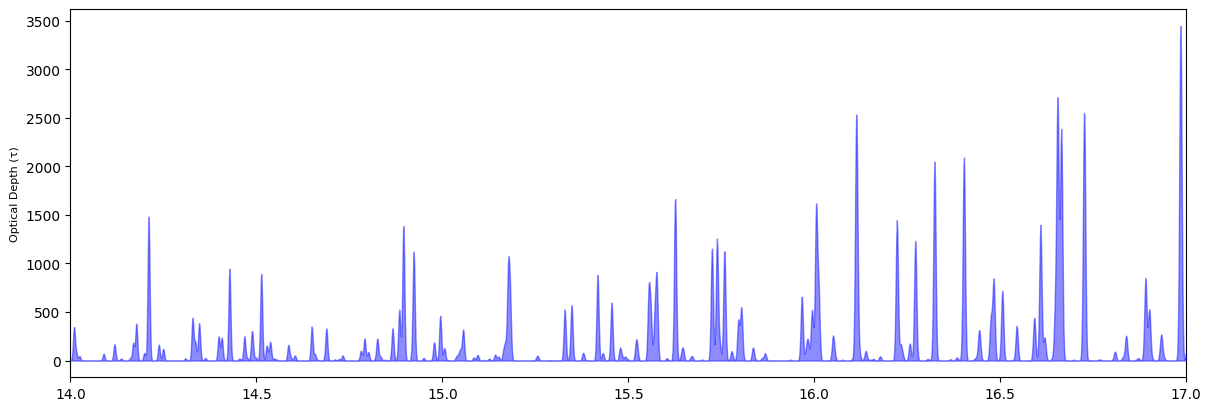

In [3]:
# --- Single molecule optical depth (profile mode) ---

odp = OpticalDepthPanel(
    wave_data=wave_grid,
    flux_data=observed_flux,
    xmin=14.0,
    xmax=17.0,
    molecule=mol_dict["H2O"],
    display_mode="profile",
    figsize=(12, 4),
)
odp.generate_plot()
odp.show()

Calculating intensity for CO2: T=300.0K, N_mol=1.00e+17, dv=1.0
Calculating intensity for CO: T=1000.0K, N_mol=1.00e+18, dv=1.0


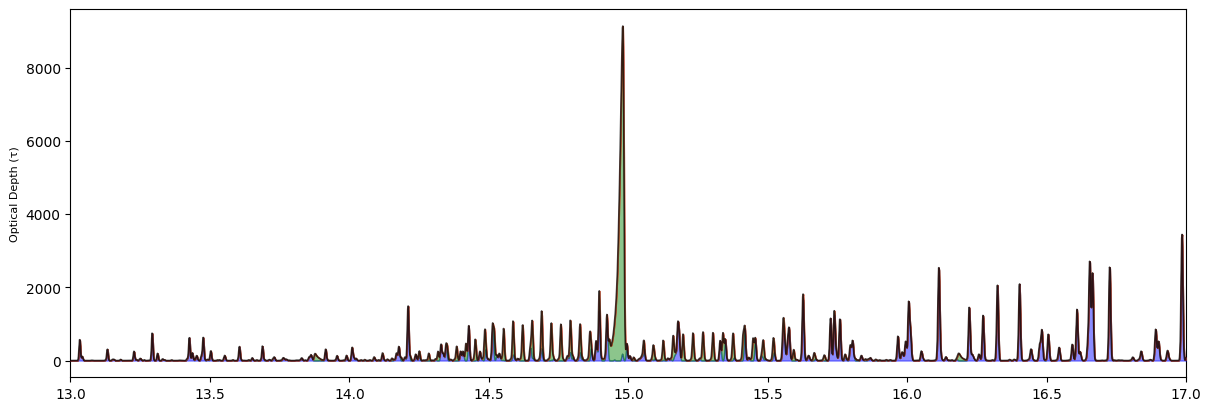

In [4]:
# --- All molecules with stacked fill ---

odp_all = OpticalDepthPanel(
    wave_data=wave_grid,
    flux_data=observed_flux,
    xmin=13.0,
    xmax=17.0,
    molecules=mol_dict,
    display_mode="profile",
    stacked_fill=True,
    show_total=True,
    figsize=(12, 4),
)
odp_all.generate_plot()
odp_all.show()

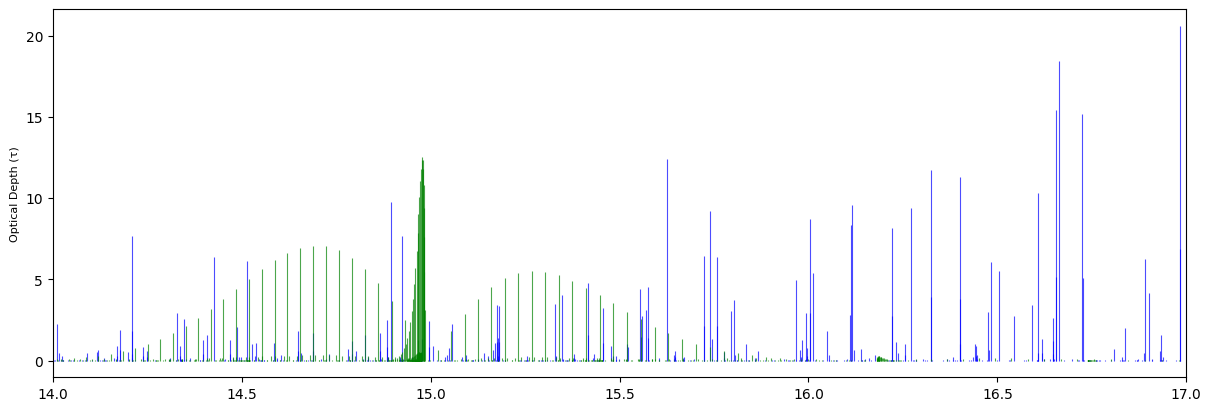

In [5]:
# --- Stem mode: per-line markers at line-center wavelengths ---

odp_stem = OpticalDepthPanel(
    wave_data=wave_grid,
    flux_data=observed_flux,
    xmin=14.0,
    xmax=17.0,
    molecules=mol_dict,
    display_mode="stem",
    figsize=(12, 4),
)
odp_stem.generate_plot()
odp_stem.show()

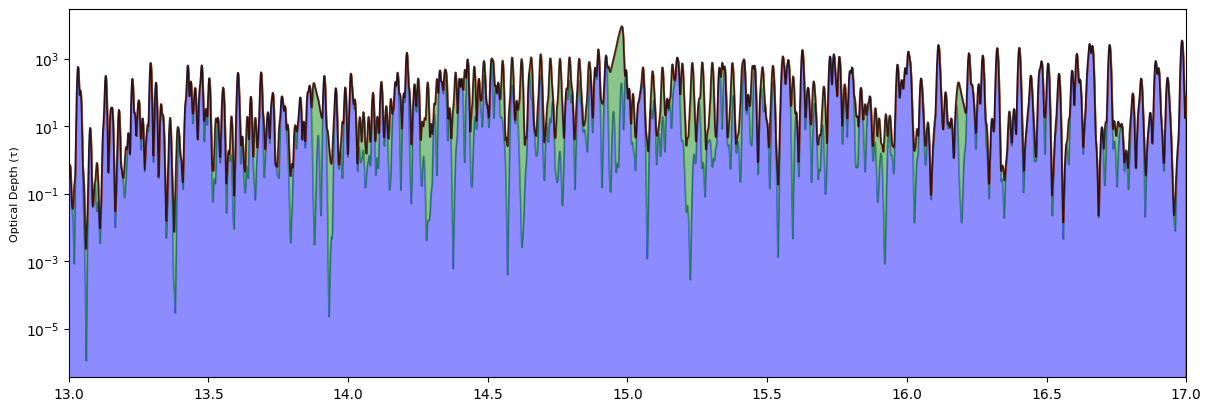

In [6]:
# --- Log scale ---

odp_log = OpticalDepthPanel(
    wave_data=wave_grid,
    flux_data=observed_flux,
    xmin=13.0,
    xmax=17.0,
    molecules=mol_dict,
    display_mode="profile",
    log_scale=True,
    figsize=(12, 4),
)
odp_log.generate_plot()
odp_log.show()

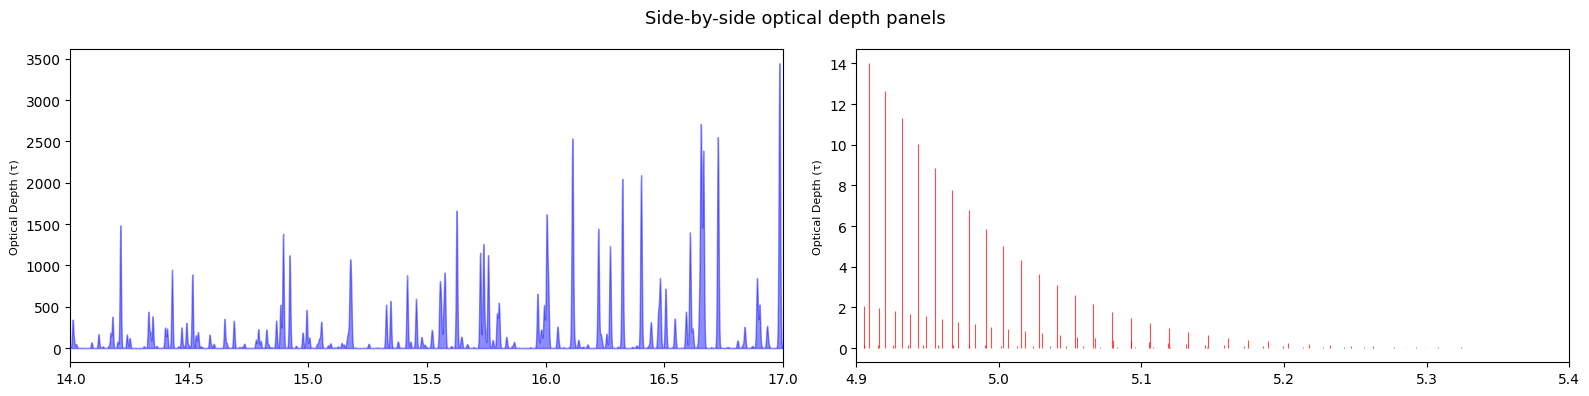

In [7]:
# --- Embed two panels side-by-side in a custom figure ---

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left: H2O region (profile)
odp_h2o = OpticalDepthPanel(
    wave_data=wave_grid, flux_data=observed_flux,
    xmin=14.0, xmax=17.0,
    molecule=mol_dict["H2O"],
    ax=axes[0],
)
odp_h2o.generate_plot()

# Right: CO region (stem)
odp_co = OpticalDepthPanel(
    wave_data=wave_grid, flux_data=observed_flux,
    xmin=4.9, xmax=5.4,
    molecule=mol_dict["CO"],
    display_mode="stem",
    ax=axes[1],
)
odp_co.generate_plot()

fig.suptitle("Side-by-side optical depth panels", fontsize=13)
fig.tight_layout()
plt.show()

## 2. OpticalDepthSpectrumPlot -- Multi-Panel Stacked Overview

`OpticalDepthSpectrumPlot` divides the full wavelength range into vertically stacked panels, each showing
the convolved tau(lambda) profile with color-coded stacked fills per molecule.

**Key parameters:**
- `n_panels` / `step` -- number of panels or wavelength width per panel
- `xlim_range` -- restrict to a sub-range
- `uniform_ylim` -- force all panels to share the same y-axis scale
- `display_mode`, `log_scale`, `show_total`, `stacked_fill` -- same as `OpticalDepthPanel`

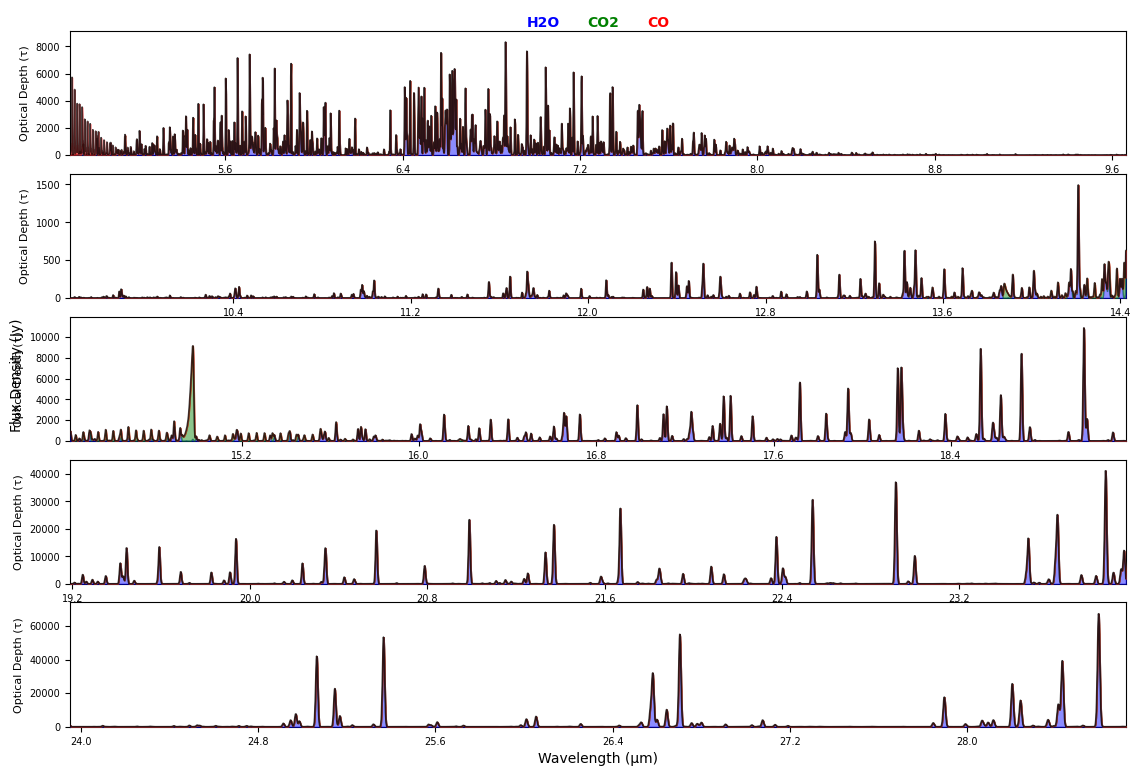

In [8]:
# --- Full-range optical depth overview with 5 panels ---

odsp = OpticalDepthSpectrumPlot(
    wave_data=wave_grid,
    flux_data=observed_flux,
    molecules=mol_dict,
    n_panels=5,
)
odsp.generate_plot()
odsp.show()

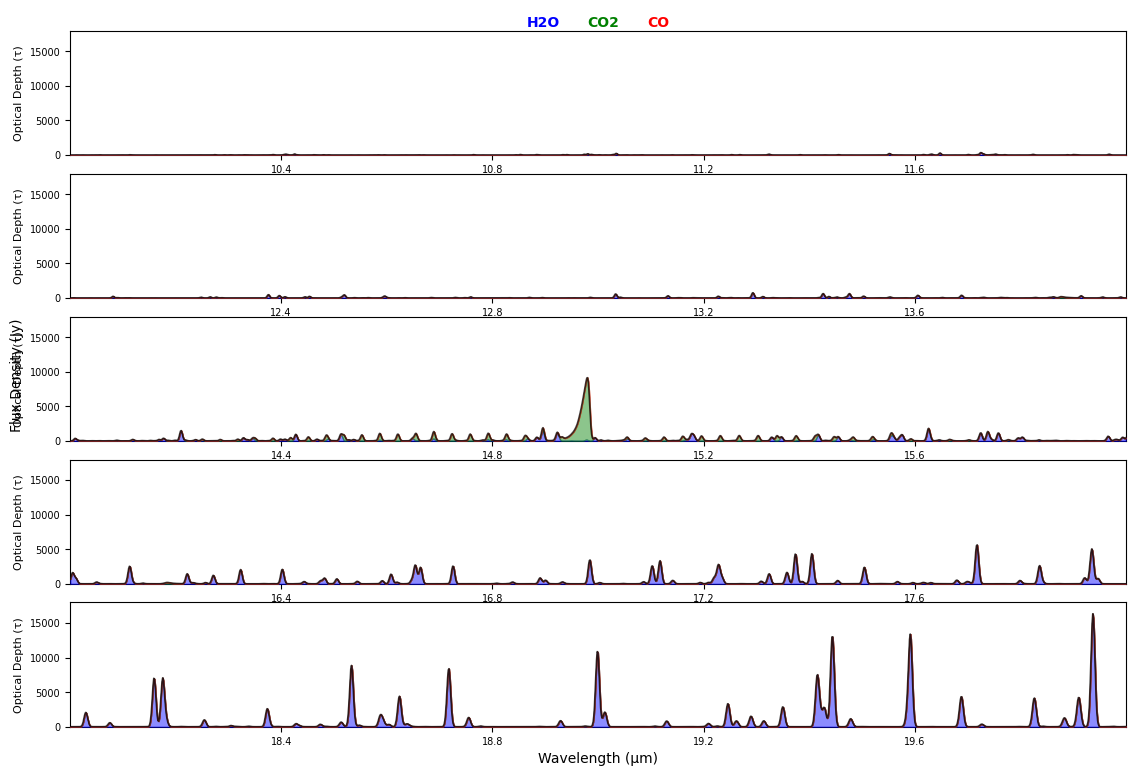

In [9]:
# --- Restrict to 10-20 um with fixed step and uniform y-limits ---

odsp_sub = OpticalDepthSpectrumPlot(
    wave_data=wave_grid,
    flux_data=observed_flux,
    molecules=mol_dict,
    xlim_range=(10.0, 20.0),
    step=2.0,
    uniform_ylim=True,
)
odsp_sub.generate_plot()
odsp_sub.show()

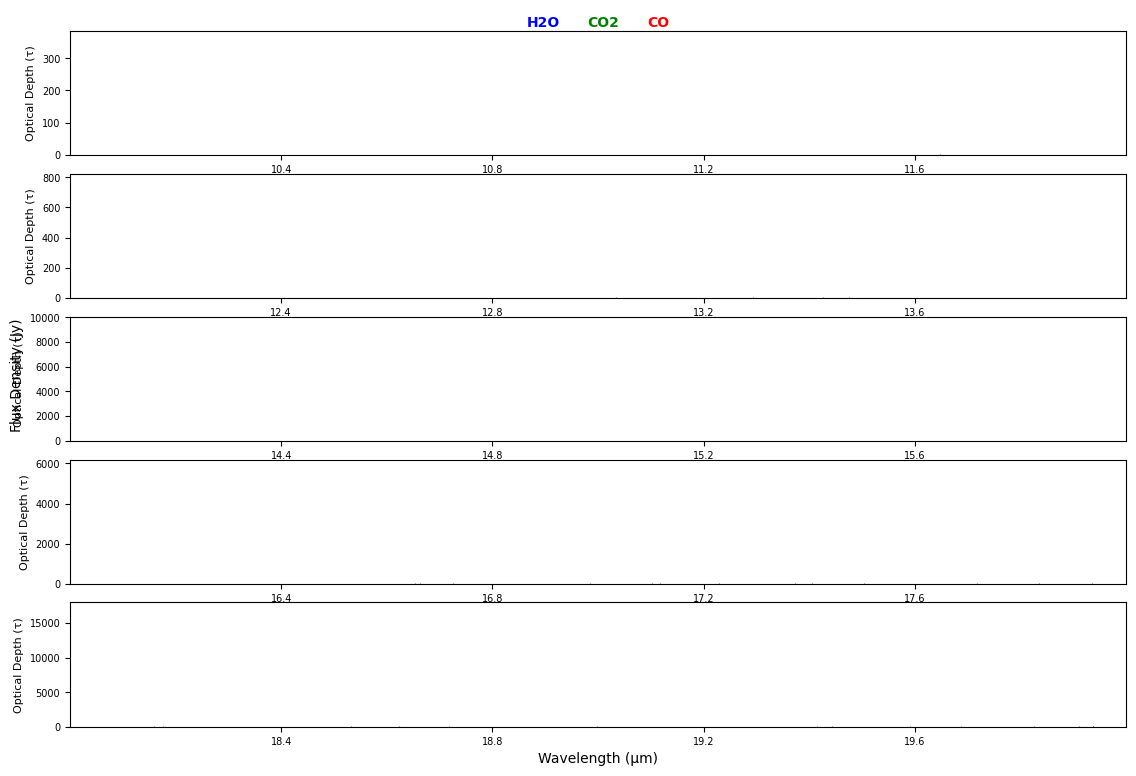

In [10]:
# --- Stem mode overview ---

odsp_stem = OpticalDepthSpectrumPlot(
    wave_data=wave_grid,
    flux_data=observed_flux,
    molecules=mol_dict,
    xlim_range=(10.0, 20.0),
    step=2.0,
    display_mode="stem",
)
odsp_stem.generate_plot()
odsp_stem.show()

## 3. Composite Stacking -- Flux + Optical Depth

Use the `+` operator (or `stack_with()`) to combine a `FullSpectrumPlot` with an `OpticalDepthSpectrumPlot`
into a single composite figure.  The panels are interleaved row-by-row:
each wavelength window gets a flux panel on top and a tau panel below.

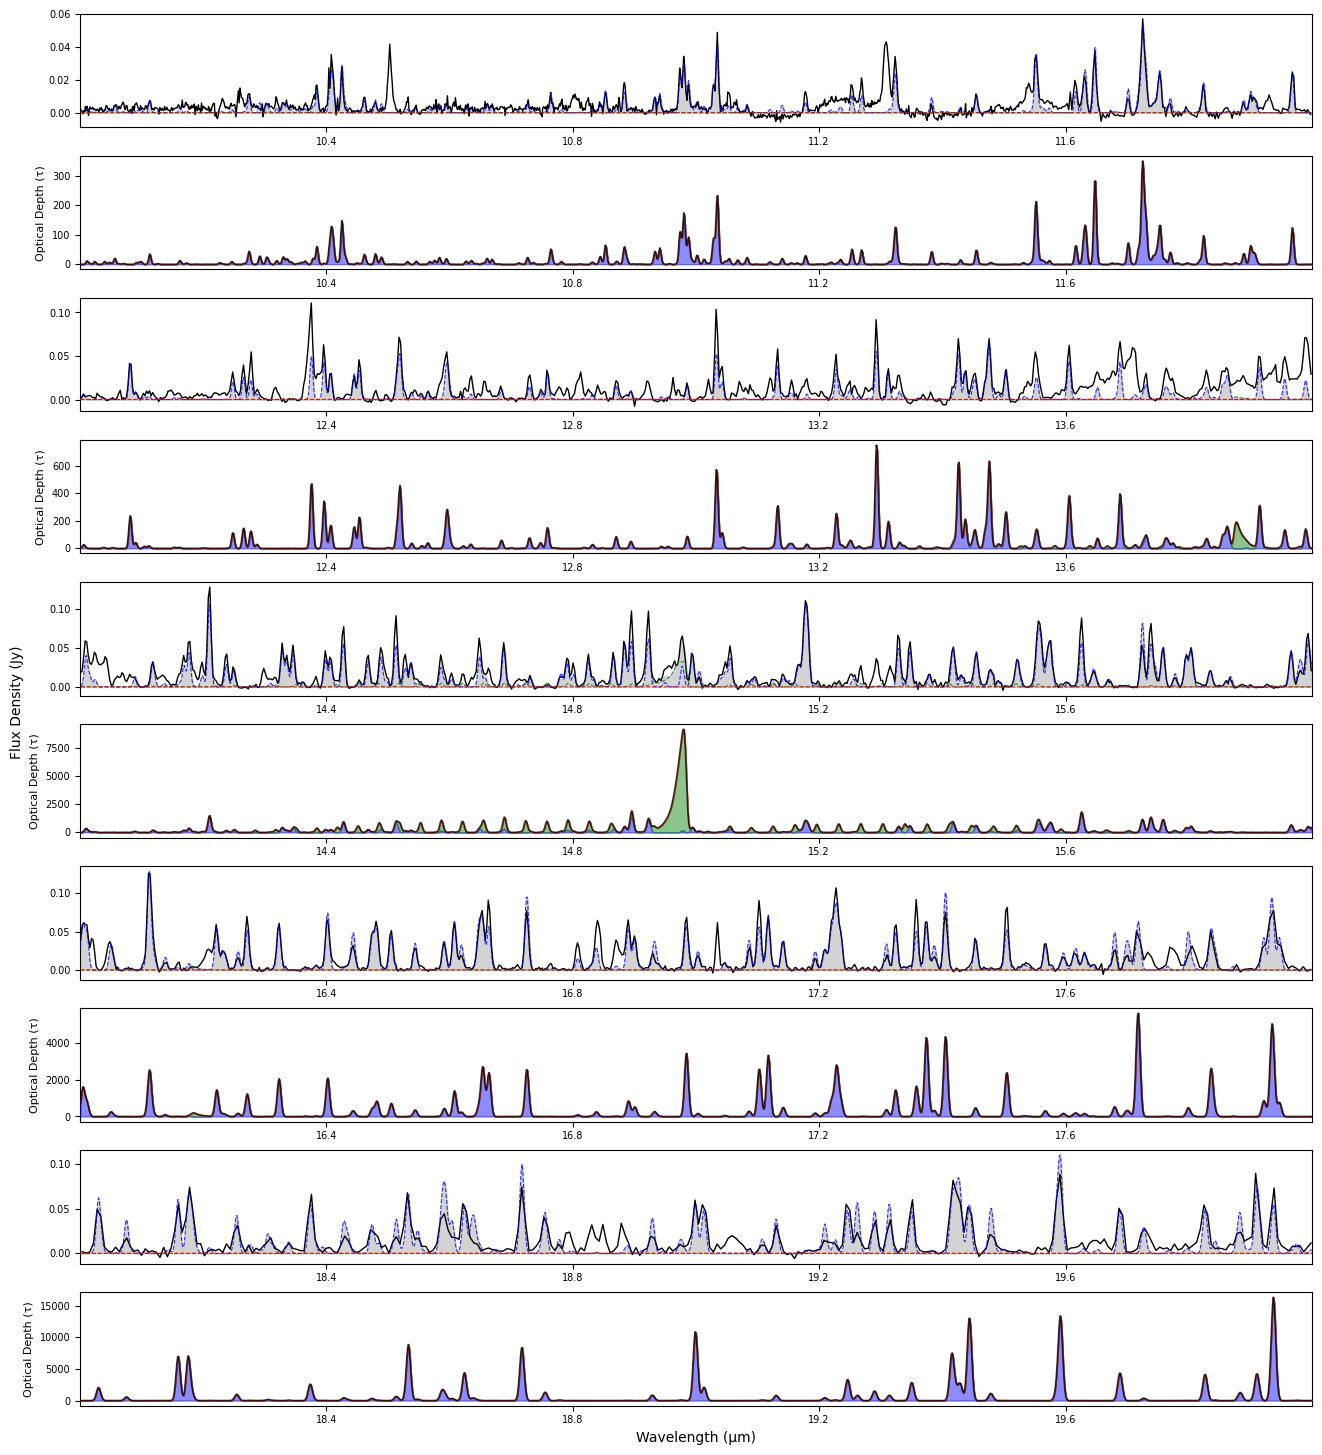

In [11]:
# --- Flux + Tau composite ---

fsp = FullSpectrumPlot(
    wave_data=wave_grid,
    flux_data=observed_flux,
    molecules=mol_dict,
    xlim_range=(10.0, 20.0),
    step=2.0,
)

odsp = OpticalDepthSpectrumPlot(
    wave_data=wave_grid,
    flux_data=observed_flux,
    molecules=mol_dict,
    xlim_range=(10.0, 20.0),
    step=2.0,
)

# Combine with + operator
composite = fsp + odsp
composite.generate_plot()
composite.show()

## 4. Theming

All optical depth plots support the same theming system as the rest of iSLAT.

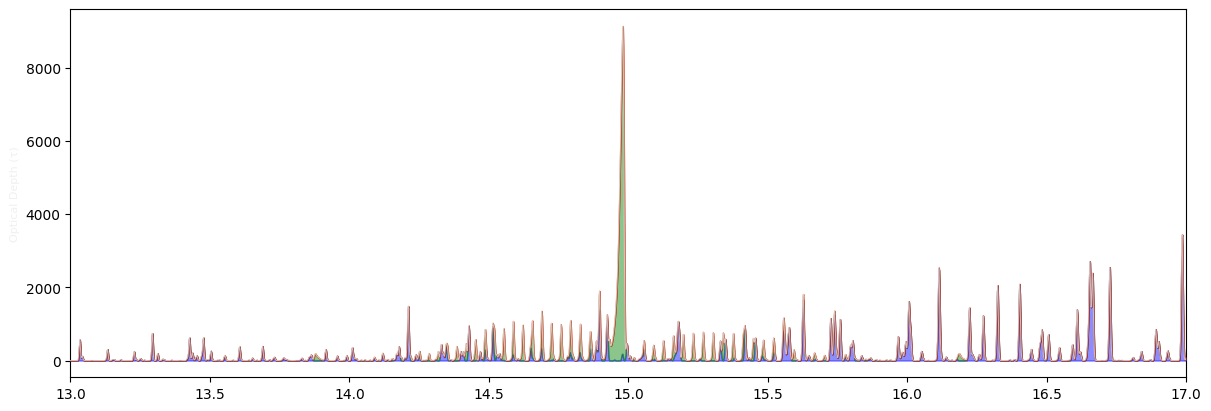

In [12]:
# --- Dark theme ---

dark_theme = load_theme("DarkTheme")

odp_dark = OpticalDepthPanel(
    wave_data=wave_grid,
    flux_data=observed_flux,
    xmin=13.0,
    xmax=17.0,
    molecules=mol_dict,
    theme=dark_theme,
    figsize=(12, 4),
)
odp_dark.generate_plot()
odp_dark.show()

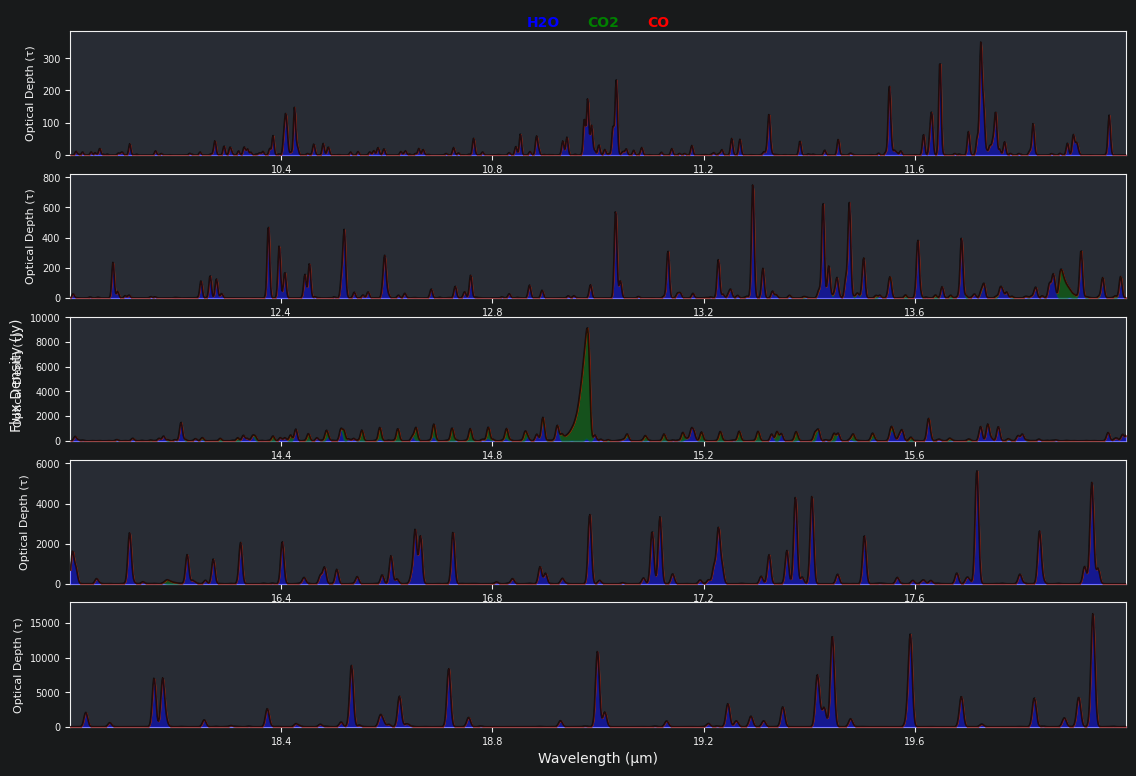

In [13]:
# --- Dark theme multi-panel ---

odsp_dark = OpticalDepthSpectrumPlot(
    wave_data=wave_grid,
    flux_data=observed_flux,
    molecules=mol_dict,
    xlim_range=(10.0, 20.0),
    n_panels=5,
    theme=dark_theme,
)
odsp_dark.generate_plot()
odsp_dark.show()

## 5. Accessing Tau Data Directly

You can also access the raw tau data programmatically via `Molecule.get_tau()` or `BasePlot.get_molecule_tau_data()`.

H2O tau profile: 18320 points
Wavelength range: 4.90 - 28.71 um
Peak tau: 67328.6844


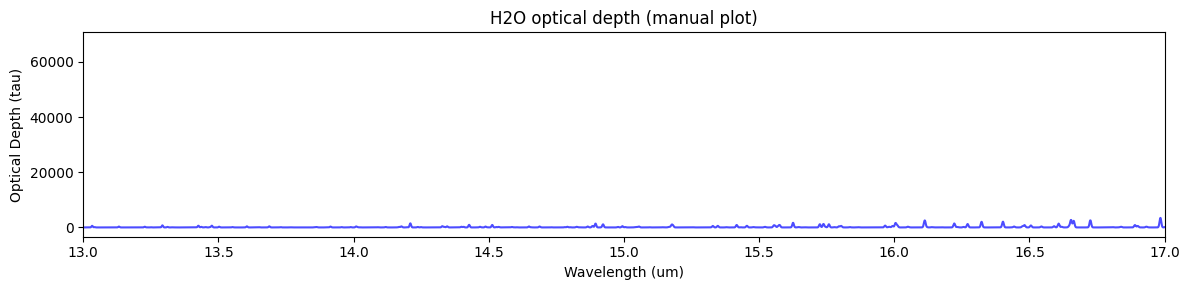

In [14]:
# --- Get tau data from a molecule ---

mol_dict["H2O"].calculate_intensity()

wavelengths, tau = mol_dict["H2O"].get_tau(return_wavelengths=True)
print(f"H2O tau profile: {len(tau)} points")
print(f"Wavelength range: {wavelengths.min():.2f} - {wavelengths.max():.2f} um")
print(f"Peak tau: {tau.max():.4f}")

# Plot manually
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(wavelengths, tau, color='blue', alpha=0.7)
ax.set_xlabel('Wavelength (um)')
ax.set_ylabel('Optical Depth (tau)')
ax.set_title('H2O optical depth (manual plot)')
ax.set_xlim(13.0, 17.0)
plt.tight_layout()
plt.show()

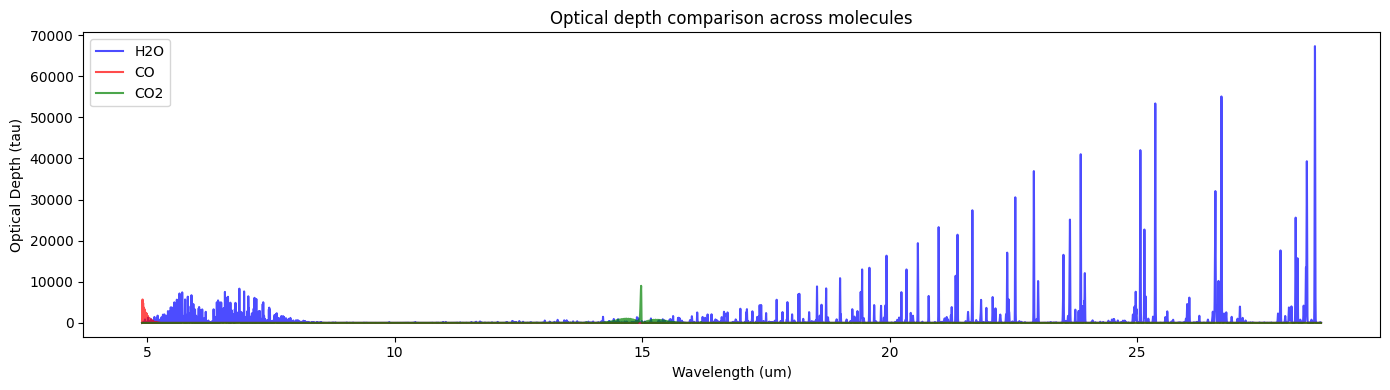

In [15]:
# --- Compare tau across molecules ---

fig, ax = plt.subplots(figsize=(14, 4))

for name in ["H2O", "CO", "CO2"]:
    mol = mol_dict[name]
    mol.calculate_intensity()
    w, t = mol.get_tau(return_wavelengths=True)
    if w is not None and t is not None:
        ax.plot(w, t, label=name, alpha=0.7, color=mol.color)

ax.set_xlabel('Wavelength (um)')
ax.set_ylabel('Optical Depth (tau)')
ax.set_title('Optical depth comparison across molecules')
ax.legend()
plt.tight_layout()
plt.show()